# Proyek Klasifikasi Gambar: [Animals]
- **Nama:** [TENGKU RYAN ADIANSYAH BANI]
- **Email:** [teukuryan111@gmail.com]
- **ID Dicoding:** [imnayr]

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library Umum dan File Handling
import os, shutil
import zipfile
import random
from random import sample
import pathlib
from pathlib import Path
import shutil
from shutil import copyfile


# Data Analysis dan Progress Bar
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files


# Pemrosesan Gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize, rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise


# Library Model Machine Learning (Deep Learning)
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf


# Membangun Arsitektur Model CNN
from tensorflow.keras import Model, layers
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (InputLayer, Conv2D, SeparableConv2D, MaxPooling2D,
                                     MaxPool2D, Dense, Flatten, Dropout, BatchNormalization)


# Data Augmentation dan Image Loading
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img


# Optimizers dan Utilitas Training
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import plot_model, to_categorical

# Pretrained Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.applications import EfficientNetB3

# Model Inference & Layer Tambahan
from keras.layers import TFSMLayer
from keras import Sequential


## Data Preparation

In [2]:
# Menginstal Library Kaggle
!pip install -q kaggle

# Mengunggah File kaggle.json
uploaded = files.upload()

# Menyimpan dan Mengamankan File Token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Mengunduh Dataset dari Kaggle
!kaggle datasets download -d antobenedetti/animals -p /content/sample_data

# Mengekstrak File Zip
!unzip -q /content/sample_data/animals.zip -d /content/sample_data/


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/antobenedetti/animals
License(s): GPL-2.0


**🔚 Hasil Akhir**

---


Setelah seluruh proses selesai:

Dataset animals siap digunakan di direktori /content/sample_data/animals/

In [3]:
import os
from PIL import Image  # Library untuk memproses gambar

def analisis_ukuran_gambar(direktori_target):
    """
    Fungsi untuk menganalisis ukuran semua gambar dalam direktori dan subdirektori.

    Args:
        direktori_target (str): Path ke direktori yang akan dianalisis

    Returns:
        dict: Dictionary berisi informasi ukuran gambar dan jumlah total gambar
    """

    # Inisialisasi dictionary untuk menyimpan ukuran gambar
    daftar_ukuran = {}
    jumlah_gambar = 0

    # Daftar ekstensi file gambar yang didukung
    ekstensi_valid = (".jpg", ".png", ".jpeg", ".webp", ".bmp", ".gif")

    # Traversing semua file dalam direktori dan subdirektori
    for root, dirs, files in os.walk(direktori_target):
        for nama_file in files:
            # Periksa apakah file memiliki ekstensi gambar yang valid
            if nama_file.lower().endswith(ekstensi_valid):
                path_lengkap = os.path.join(root, nama_file)

                try:
                    # Buka gambar menggunakan PIL
                    with Image.open(path_lengkap) as img:
                        # Simpan ukuran gambar (lebar, tinggi) ke dictionary
                        daftar_ukuran[nama_file] = img.size
                        jumlah_gambar += 1
                except Exception as e:
                    # Tangani error jika gagal membuka gambar
                    print(f"[ERROR] Gagal memproses {path_lengkap}: {str(e)}")

    return {
        'daftar_ukuran': daftar_ukuran,
        'total_gambar': jumlah_gambar
    }

# Contoh penggunaan fungsi
if __name__ == "__main__":
    # Path ke direktori yang akan dianalisis
    folder_target = "/content/sample_data/animals"

    # Panggil fungsi analisis
    hasil_analisis = analisis_ukuran_gambar(folder_target)

    # Tampilkan hasil analisis
    print("=== LAPORAN UKURAN GAMBAR ===")
    for nama, ukuran in hasil_analisis['daftar_ukuran'].items():
        print(f"Gambar: {nama} \t-> Ukuran: {ukuran[0]}x{ukuran[1]} piksel")

    print(f"\nTOTAL GAMBAR YANG DIANALISIS: {hasil_analisis['total_gambar']}")
    print(f"DIREKTORI TARGET: '{folder_target}'")

=== LAPORAN UKURAN GAMBAR ===
Gambar: horse2527.jpg 	-> Ukuran: 225x225 piksel
Gambar: horse2070.jpg 	-> Ukuran: 259x194 piksel
Gambar: horse1828.jpg 	-> Ukuran: 64x64 piksel
Gambar: horse1356.jpg 	-> Ukuran: 1024x681 piksel
Gambar: horse300.jpg 	-> Ukuran: 256x256 piksel
Gambar: horse1143.jpg 	-> Ukuran: 1024x768 piksel
Gambar: horse242.jpg 	-> Ukuran: 64x64 piksel
Gambar: horse1303.jpg 	-> Ukuran: 684x1024 piksel
Gambar: horse1346.jpg 	-> Ukuran: 349x296 piksel
Gambar: horse516.jpg 	-> Ukuran: 1024x683 piksel
Gambar: horse146.jpg 	-> Ukuran: 64x64 piksel
Gambar: horse2640.jpg 	-> Ukuran: 248x203 piksel
Gambar: horse843.jpg 	-> Ukuran: 500x375 piksel
Gambar: horse2475.jpg 	-> Ukuran: 299x168 piksel
Gambar: horse1109.jpg 	-> Ukuran: 1024x681 piksel
Gambar: horse71.jpg 	-> Ukuran: 64x64 piksel
Gambar: horse820.jpg 	-> Ukuran: 1024x683 piksel
Gambar: horse2406.jpg 	-> Ukuran: 251x201 piksel
Gambar: horse2538.jpg 	-> Ukuran: 275x183 piksel
Gambar: horse2031.jpg 	-> Ukuran: 64x64 piksel
Ga

### Data Loading

In [4]:
import os
import shutil

def gabungkan_dataset(train_dir, valid_dir, output_dir):
    """
    Menggabungkan dataset dari direktori pelatihan dan validasi ke satu direktori output.

    Args:
        train_dir (str): Path ke direktori data pelatihan
        valid_dir (str): Path ke direktori data validasi
        output_dir (str): Path ke direktori output gabungan

    Returns:
        dict: Dictionary berisi statistik penggabungan dataset
    """

    # Membuat direktori output jika belum ada
    os.makedirs(output_dir, exist_ok=True)

    # Inisialisasi variabel untuk statistik
    statistik = {
        'total_kategori': 0,
        'file_train': 0,
        'file_valid': 0,
        'kategori': []
    }

    # Fungsi untuk menyalin file dari sumber ke tujuan
    def salin_kategori(sumber_dir, jenis_data):
        """
        Fungsi helper untuk menyalin file dalam kategori tertentu

        Args:
            sumber_dir (str): Direktori sumber data
            jenis_data (str): Jenis data ('train' atau 'valid')
        """
        nonlocal statistik

        # Iterasi melalui semua kategori di direktori sumber
        for kategori in os.listdir(sumber_dir):
            path_kategori = os.path.join(sumber_dir, kategori)

            # Pastikan ini adalah direktori (bukan file)
            if os.path.isdir(path_kategori):
                path_tujuan = os.path.join(output_dir, kategori)

                # Jika kategori belum ada di statistik, tambahkan
                if kategori not in statistik['kategori']:
                    statistik['kategori'].append(kategori)
                    statistik['total_kategori'] += 1

                # Salin seluruh isi direktori kategori
                try:
                    shutil.copytree(path_kategori, path_tujuan, dirs_exist_ok=True)

                    # Hitung jumlah file yang disalin
                    jumlah_file = len(os.listdir(path_kategori))
                    if jenis_data == 'train':
                        statistik['file_train'] += jumlah_file
                    else:
                        statistik['file_valid'] += jumlah_file

                except Exception as e:
                    print(f"Gagal menyalin {path_kategori}: {str(e)}")

    # Proses data pelatihan
    print("Memproses data pelatihan...")
    salin_kategori(train_dir, 'train')

    # Proses data validasi
    print("Memproses data validasi...")
    salin_kategori(valid_dir, 'valid')

    # Hitung total file gabungan
    statistik['total_file'] = statistik['file_train'] + statistik['file_valid']

    return statistik

# Contoh penggunaan
if __name__ == "__main__":
    # Path direktori
    train_dir = "/content/sample_data/animals/train"
    valid_dir = "/content/sample_data/animals/val"
    combined_dir = "/content/sample_data/animals/dataset"

    # Jalankan fungsi penggabungan
    hasil = gabungkan_dataset(train_dir, valid_dir, combined_dir)

    # Tampilkan laporan
    print("\n=== LAPORAN PENGGABUNGAN DATASET ===")
    print(f"Total Kategori: {hasil['total_kategori']}")
    print(f"File Pelatihan: {hasil['file_train']}")
    print(f"File Validasi: {hasil['file_valid']}")
    print(f"Total File Gabungan: {hasil['total_file']}")
    print(f"Direktori Output: '{combined_dir}'")
    print("Daftar Kategori:", ", ".join(hasil['kategori']))

Memproses data pelatihan...
Memproses data validasi...

=== LAPORAN PENGGABUNGAN DATASET ===
Total Kategori: 5
File Pelatihan: 13474
File Validasi: 1497
Total File Gabungan: 14971
Direktori Output: '/content/sample_data/animals/dataset'
Daftar Kategori: horse, lion, cat, dog, elephant


**menggabungkan folder train dan val menjadi 1 folder dengan nama dataset**

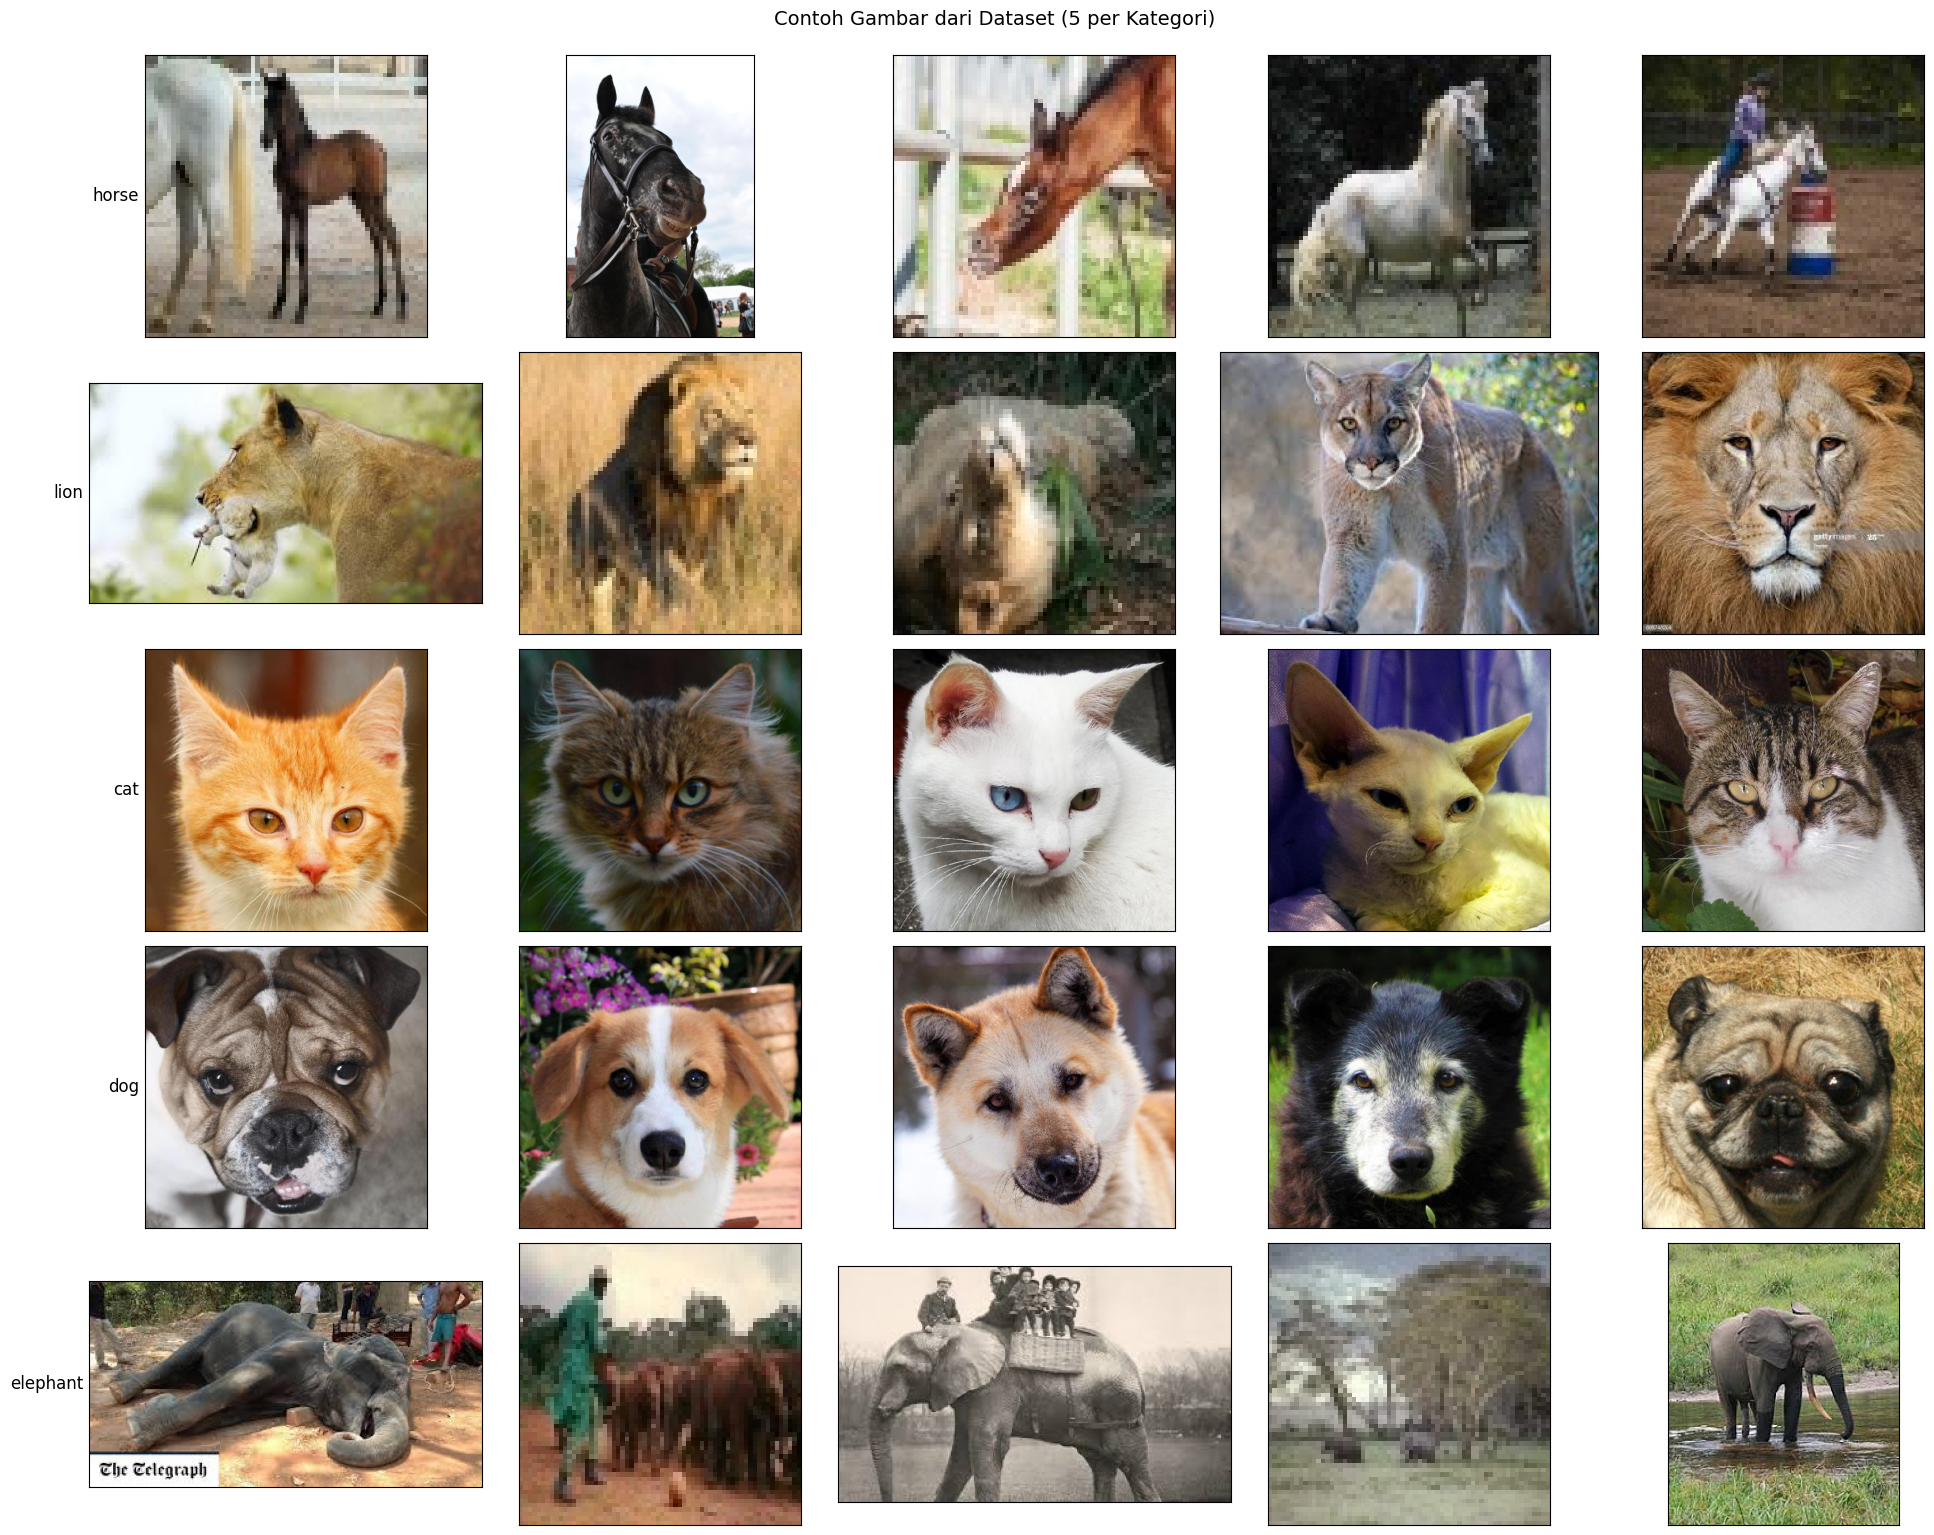


=== INFORMASI DATASET ===
Jumlah Kategori: 5
Total Gambar: 13725
Daftar Kategori: horse, lion, cat, dog, elephant


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from random import sample

def visualisasi_contoh_gambar(dataset_path, contoh_per_kategori=5):
    """
    Menampilkan contoh gambar dari setiap kategori dalam dataset secara visual.

    Args:
        dataset_path (str): Path ke direktori dataset utama
        contoh_per_kategori (int): Jumlah contoh gambar yang akan ditampilkan per kategori

    Returns:
        dict: Dictionary berisi informasi tentang gambar yang ditampilkan
    """

    # 1. Membaca struktur dataset
    # Dictionary untuk menyimpan daftar file gambar per kategori
    gambar_per_kategori = {}

    # Path ke subdirektori dataset
    path_dataset = os.path.join(dataset_path, "dataset")

    # Validasi path dataset
    if not os.path.exists(path_dataset):
        raise FileNotFoundError(f"Direktori dataset tidak ditemukan: {path_dataset}")

    # 2. Mengumpulkan informasi gambar per kategori
    for kategori in os.listdir(path_dataset):
        path_kategori = os.path.join(path_dataset, kategori)

        # Pastikan ini adalah direktori (bukan file)
        if os.path.isdir(path_kategori):
            # Dapatkan daftar file gambar dalam kategori
            file_gambar = [f for f in os.listdir(path_kategori)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

            if file_gambar:
                gambar_per_kategori[kategori] = file_gambar

    # 3. Persiapan visualisasi
    jumlah_kategori = len(gambar_per_kategori)

    if jumlah_kategori == 0:
        print("Tidak ditemukan kategori dengan gambar di dataset.")
        return

    # Buat figure dengan ukuran dinamis
    # - Lebar: 4 inci per kolom
    # - Tinggi: 3 inci per baris (kategori)
    fig, axes = plt.subplots(
        nrows=jumlah_kategori,
        ncols=contoh_per_kategori,
        figsize=(4 * contoh_per_kategori, 3 * jumlah_kategori)
    )

    # Jika hanya ada 1 kategori, konversi axes ke bentuk 2D
    if jumlah_kategori == 1:
        axes = np.expand_dims(axes, axis=0)

    # 4. Menampilkan contoh gambar
    for i, (kategori, daftar_gambar) in enumerate(gambar_per_kategori.items()):
        # Pilih contoh gambar secara acak (tanpa pengulangan)
        contoh_gambar = sample(daftar_gambar, min(contoh_per_kategori, len(daftar_gambar)))

        for j, nama_file in enumerate(contoh_gambar):
            # Baca gambar
            path_gambar = os.path.join(path_dataset, kategori, nama_file)
            try:
                with Image.open(path_gambar) as img:
                    # Tampilkan gambar
                    axes[i,j].imshow(img)
                    # Atur judul hanya untuk gambar pertama di setiap baris
                    if j == 0:
                        axes[i,j].set_ylabel(kategori, fontsize=12, rotation=0, ha='right', va='center')
                    # Hilangkan ticks
                    axes[i,j].set_xticks([])
                    axes[i,j].set_yticks([])
            except Exception as e:
                print(f"Gagal memuat gambar {path_gambar}: {str(e)}")
                axes[i,j].axis('off')  # Matikan axis jika gambar gagal dimuat

    # 5. Penyempurnaan tampilan
    plt.tight_layout()
    plt.suptitle(f"Contoh Gambar dari Dataset ({contoh_per_kategori} per Kategori)", y=1.02, fontsize=14)
    plt.show()

    return {
        'jumlah_kategori': jumlah_kategori,
        'total_gambar': sum(len(g) for g in gambar_per_kategori.values()),
        'kategori': list(gambar_per_kategori.keys())
    }

# Contoh penggunaan
if __name__ == "__main__":
    # Path ke dataset
    dataset_path = "/content/sample_data/animals"

    # Jalankan fungsi visualisasi
    info_dataset = visualisasi_contoh_gambar(dataset_path, contoh_per_kategori=5)

    # Tampilkan informasi dataset
    if info_dataset:
        print("\n=== INFORMASI DATASET ===")
        print(f"Jumlah Kategori: {info_dataset['jumlah_kategori']}")
        print(f"Total Gambar: {info_dataset['total_gambar']}")
        print("Daftar Kategori:", ", ".join(info_dataset['kategori']))

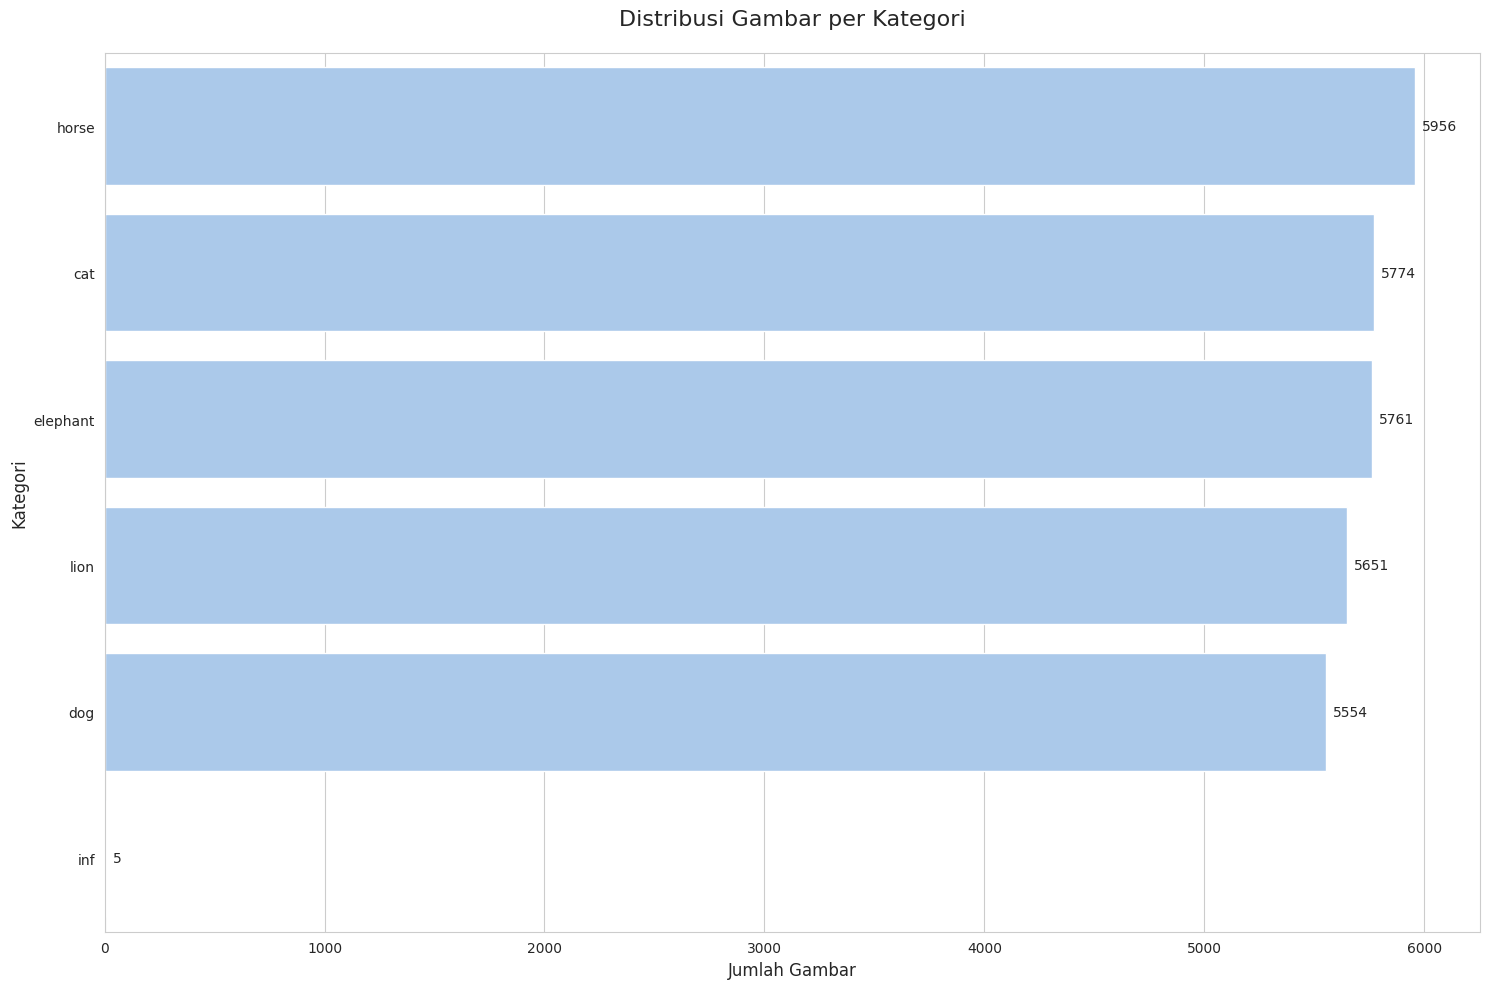


=== HASIL ANALISIS DATASET ===
Total Gambar: 28701
Jumlah Kategori: 6

Distribusi per Kategori:
- horse: 5956 gambar
- cat: 5774 gambar
- elephant: 5761 gambar
- lion: 5651 gambar
- dog: 5554 gambar
- inf: 5 gambar


In [6]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

def analisis_distribusi_dataset(dataset_path):
    """
    Menganalisis distribusi gambar dalam dataset dan menampilkan visualisasi.

    Args:
        dataset_path (str): Path ke direktori dataset utama

    Returns:
        tuple: (DataFrame berisi informasi dataset, dict berisi distribusi per kategori)
    """

    # 1. Inisialisasi struktur data untuk menyimpan informasi
    data_koleksi = {
        'path_file': [],      # Menyimpan path lengkap file
        'nama_file': [],      # Menyimpan nama file saja
        'kategori': [],       # Menyimpan label kategori
        'ekstensi': []        # Menyimpan tipe file
    }

    # Dictionary untuk menghitung distribusi per kategori
    distribusi_kategori = defaultdict(int)

    # 2. Traversing direktori dataset
    for root_dir, sub_dirs, files in os.walk(dataset_path):
        # Lewati jika tidak ada file
        if not files:
            continue

        # Dapatkan kategori dari nama folder terakhir
        kategori = os.path.basename(root_dir)

        # 3. Proses setiap file dalam direktori
        for file in files:
            # Dapatkan ekstensi file
            _, ext = os.path.splitext(file)
            ext = ext.lower()  # Normalisasi ke lowercase

            # Hanya proses file gambar
            if ext not in ['.jpg', '.jpeg', '.png', '.bmp', '.gif']:
                continue

            # Bangun path lengkap
            path_lengkap = os.path.join(root_dir, file)

            # Simpan data
            data_koleksi['path_file'].append(path_lengkap)
            data_koleksi['nama_file'].append(file)
            data_koleksi['kategori'].append(kategori)
            data_koleksi['ekstensi'].append(ext)

            # Hitung distribusi
            distribusi_kategori[kategori] += 1

    # 4. Konversi ke DataFrame
    df_dataset = pd.DataFrame(data_koleksi)

    # 5. Visualisasi distribusi
    plt.figure(figsize=(15, 10))

    # Atur style plot
    sns.set_style("whitegrid")
    sns.set_palette("pastel")

    # Buat countplot
    ax = sns.countplot(
        data=df_dataset,
        y='kategori',
        order=df_dataset['kategori'].value_counts().index
    )

    # Tambahkan anotasi
    ax.set_title('Distribusi Gambar per Kategori', fontsize=16, pad=20)
    ax.set_xlabel('Jumlah Gambar', fontsize=12)
    ax.set_ylabel('Kategori', fontsize=12)

    # Tambahkan nilai di setiap bar
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_width())}',
            (p.get_width(), p.get_y() + p.get_height()/2.),
            ha='left', va='center',
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

    return df_dataset, dict(distribusi_kategori)

# Contoh penggunaan
if __name__ == "__main__":
    # Path ke dataset
    path_dataset = "/content/sample_data/animals"

    # Jalankan analisis
    df_data, distribusi = analisis_distribusi_dataset(path_dataset)

    # Tampilkan informasi
    print("\n=== HASIL ANALISIS DATASET ===")
    print(f"Total Gambar: {len(df_data)}")
    print(f"Jumlah Kategori: {len(distribusi)}")
    print("\nDistribusi per Kategori:")
    for kategori, jumlah in sorted(distribusi.items(), key=lambda x: x[1], reverse=True):
        print(f"- {kategori}: {jumlah} gambar")

### Data Preprocessing

In [7]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,30)
    return rotate(img, sudut)

# Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,30)
    return rotate(img, -sudut)

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(shear=0.2)
    shear_image = warp(img, transform, mode="wrap")
    return shear_image

# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'shear image': sheared
                  }

images_path="/content/sample_data/animals/dataset" # Path untuk gambar asli
augmented_path="/content/sample_data/animals/dataset-augmented" # Path untuk gambar yang sudah diaugmentasi
images=[] # Penyimpanan gambar yang telah melalui pra-pemrosesan

# Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
for class_folder in os.listdir(images_path):
    class_path = os.path.join(images_path, class_folder)
    if os.path.isdir(class_path):
        for im in os.listdir(class_path):
            images.append(os.path.join(class_path, im))

images_to_generate = 10000
i = 1

while i <= images_to_generate:
    image = random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image = original_image.copy()

        # Ambil label dari nama folder
        label = os.path.basename(os.path.dirname(image))
        save_dir = os.path.join(augmented_path, label)
        os.makedirs(save_dir, exist_ok=True)

        # Terapkan transformasi acak
        n = 0
        transformation_count = random.randint(1, len(transformations))  # jumlah transformasi yang akan diterapkan

        while n < transformation_count:
            key = random.choice(list(transformations))  # ambil nama transformasi acak
            transformed_image = transformations[key](transformed_image)
            n += 1

        # Simpan hasil gambar
        new_image_path = os.path.join(save_dir, f"augmented_image_{i}.jpg")
        transformed_image = img_as_ubyte(transformed_image)
        cv2.imwrite(new_image_path, transformed_image)
        i += 1

    except Exception as e:
        print(f'Could not process image {image} : {e}, skipping...')

Could not process image /content/sample_data/animals/dataset/elephant/elephant2732.png : OpenCV(4.11.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:843: error: (-215:Assertion failed) image.channels() == 1 || image.channels() == 3 || image.channels() == 4 in function 'imwrite_'
, skipping...
Could not process image /content/sample_data/animals/dataset/lion/lion2674.png : OpenCV(4.11.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:843: error: (-215:Assertion failed) image.channels() == 1 || image.channels() == 3 || image.channels() == 4 in function 'imwrite_'
, skipping...
Could not process image /content/sample_data/animals/dataset/elephant/elephant2732.png : OpenCV(4.11.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:843: error: (-215:Assertion failed) image.channels() == 1 || image.channels() == 3 || image.channels() == 4 in function 'imwrite_'
, skipping...
Could not process image /content/sample_data/animals/dataset/lion/lion2674.png : OpenCV(4.11.0) /io/opencv/modules/imgcodec

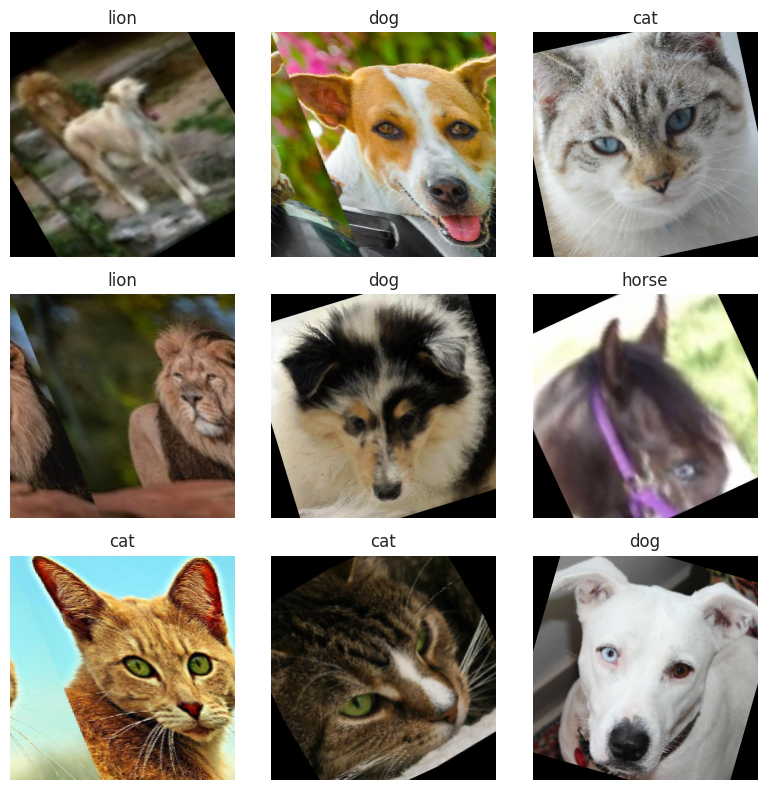

In [8]:
# Membuat figure dan axes untuk subplot 3x3 dengan ukuran 8x8 inci
fig, axs = plt.subplots(3, 3, figsize=(8, 8))

# Loop melalui setiap subplot (3 baris x 3 kolom)
for i in range(3):
    for j in range(3):
        # Memilih gambar secara acak dari list 'images'
        img_path = random.choice(images)
        # Membaca gambar menggunakan io.imread
        img = io.imread(img_path)
        # Mengambil label dari nama folder parent gambar
        label = os.path.basename(os.path.dirname(img_path))

        # Membuat salinan gambar untuk ditransformasi
        transformed = img.copy()
        # Melakukan 1 atau 2 transformasi acak pada gambar
        for _ in range(random.randint(1, 2)):
            # Memilih transformasi secara acak dari dictionary 'transformations'
            transformed = random.choice(list(transformations.values()))(transformed)

        # Menampilkan gambar yang sudah ditransformasi di subplot
        axs[i, j].imshow(transformed)
        # Menghilangkan axis/ticker pada subplot
        axs[i, j].axis("off")
        # Menambahkan judul subplot berdasarkan label
        axs[i, j].set_title(label)

# Mengatur layout agar tidak overlap antar subplot
plt.tight_layout()
# Menampilkan figure
plt.show()

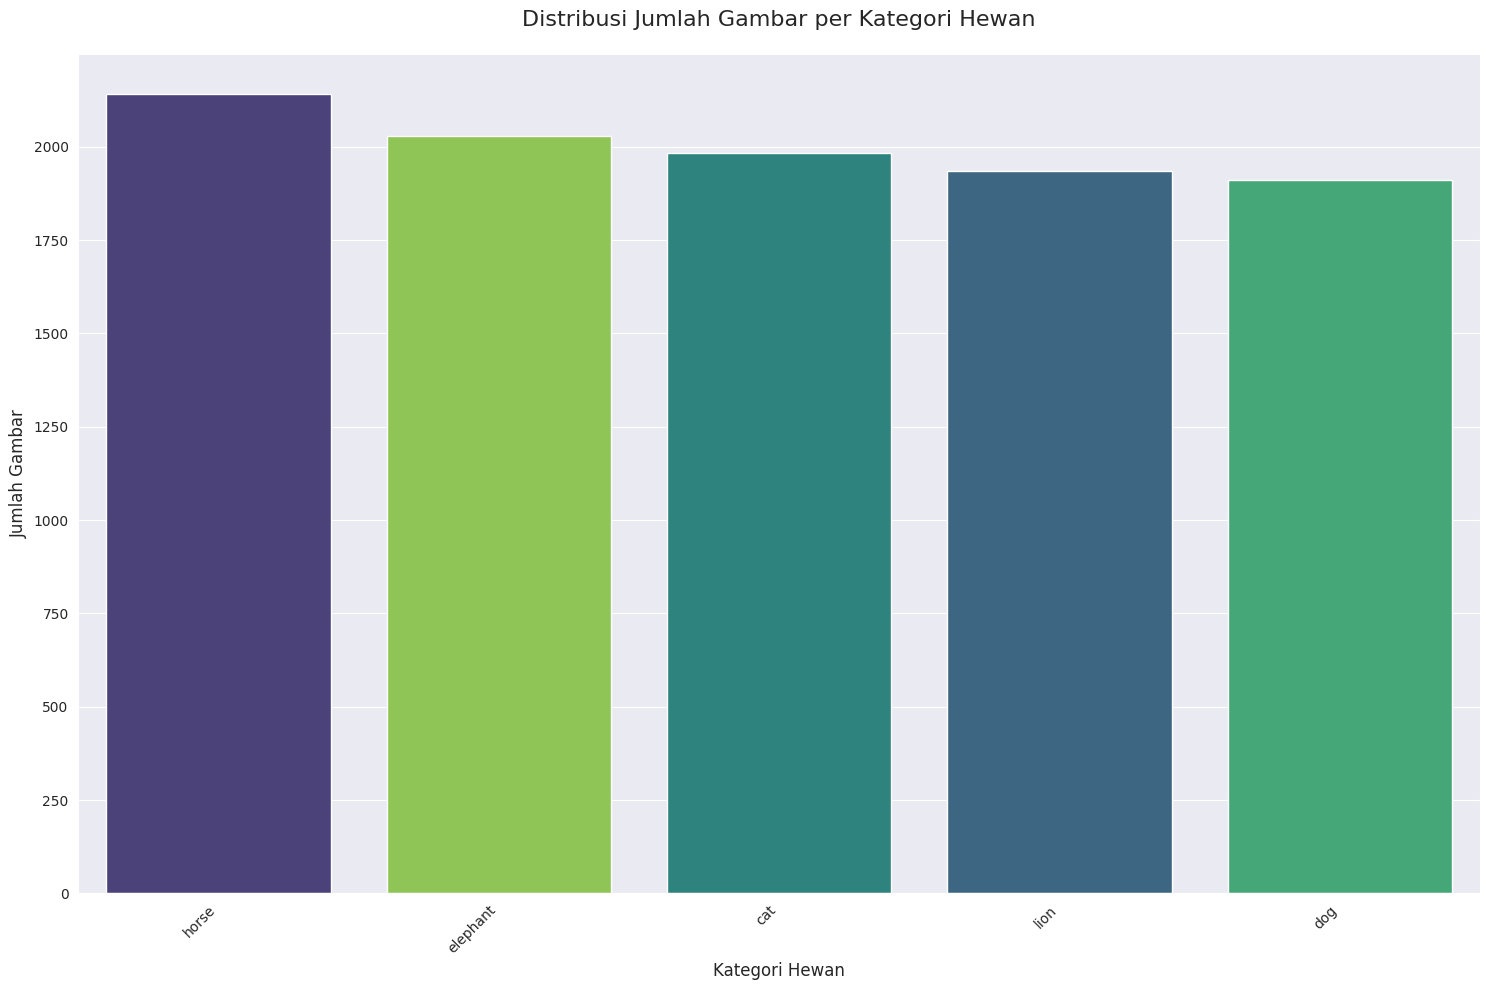

In [9]:
# IMPORT LIBRARY YANG DIBUTUHKAN
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DEFINISI PATH DATASET
dataset_root_path = "/content/sample_data/animals/dataset-augmented"

# 2. INISIALISASI LIST UNTUK MENYIMPAN INFORMASI
image_paths = []    # Menyimpan path lengkap gambar
image_names = []    # Menyimpan nama file gambar
image_labels = []   # Menyimpan label/kategori gambar

# 3. EKSTRAKSI INFORMASI DATASET
for root_dir, sub_dirs, files in os.walk(dataset_root_path):
    for filename in files:
        # Membuat path lengkap untuk setiap gambar
        full_image_path = os.path.join(root_dir, filename)
        image_paths.append(full_image_path)

        image_names.append(filename)

        # Mengambil label dari nama folder terakhir
        label = os.path.basename(root_dir)
        image_labels.append(label)

# 4. MEMBUAT DATAFRAME
dataset_df = pd.DataFrame({
    'image_path': image_paths,
    'image_name': image_names,
    'category': image_labels
})

# 5. VISUALISASI DISTRIBUSI - VERSI YANG DIPERBAIKI
plt.figure(figsize=(15, 10))
sns.set_style("darkgrid")

# PERBAIKAN: Menggunakan parameter hue dan legend=False sesuai warning
category_distribution_plot = sns.countplot(
    data=dataset_df,
    x='category',
    hue='category',  # Menambahkan parameter hue
    palette='viridis',
    legend=False,    # Menonaktifkan legend karena redundan
    order=dataset_df['category'].value_counts().index
)

# Menambahkan judul dan label
plt.title('Distribusi Jumlah Gambar per Kategori Hewan', fontsize=16, pad=20)
plt.xlabel('Kategori Hewan', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)

# Formatting tambahan
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Split Dataset

In [10]:
# Path ke dataset awal
mypath = '/content/sample_data/animals/dataset'  # Lokasi direktori dataset yang berisi folder kelas dan file gambar

# Kumpulkan path file dan label
file_name = []  # List untuk menyimpan nama file
labels = []     # List untuk menyimpan label (nama folder sebagai kelas)
full_path = []  # List untuk menyimpan path lengkap setiap file

# Iterasi melalui folder dan file di dalam direktori dataset
for path, subdirs, files in os.walk(mypath):  # os.walk digunakan untuk menelusuri semua folder dan file secara rekursif
    for name in files:  # Iterasi melalui semua file dalam folder
        full_path.append(os.path.join(path, name))  # Menyimpan path lengkap file
        labels.append(os.path.basename(path))  # Menyimpan label (nama folder tempat file berada)
        file_name.append(name)  # Menyimpan nama file

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path": full_path, 'file_name': file_name, "labels": labels})
# Membuat dataframe dengan kolom "path", "file_name", dan "labels"

# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()  # Kelompokkan data berdasarkan label dan hitung jumlah gambar per label

,0
labels,
cat,2737
dog,2627
elephant,2732
horse,2951
lion,2678


In [11]:
# Mengimpor fungsi untuk membagi data menjadi subset
from sklearn.model_selection import train_test_split

# Memisahkan data fitur (X) dan label (y)
X = df['path']  # X berisi path file gambar
y = df['labels']  # y berisi label (kelas) gambar

# Membagi data menjadi data latih (70%) dan data sementara (30%, yang akan dibagi lagi menjadi validasi dan pengujian)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,  # Data yang akan dibagi
    test_size=0.3,  # Proporsi data sementara (validasi + pengujian) adalah 30%
    stratify=y,  # Memastikan distribusi label sama di setiap subset
    random_state=300  # Seed untuk memastikan pembagian data dapat direproduksi
)

# Membagi data sementara menjadi data validasi (15% total) dan data pengujian (15% total)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,  # Data sementara yang akan dibagi
    test_size=0.5,  # Proporsi data pengujian terhadap data sementara adalah 50%
    stratify=y_temp,  # Memastikan distribusi label sama di subset validasi dan pengujian
    random_state=300  # Seed untuk memastikan pembagian data dapat direproduksi
)

# Sekarang dataset telah dibagi menjadi 3 bagian:
# - X_train, y_train: data latih (70%)
# - X_valid, y_valid: data validasi (15%)
# - X_test, y_test: data pengujian (15%)

In [12]:
# Satukan data latih, validasi, dan pengujian ke dalam masing-masing dataframe
df_train = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})  # Data latih
df_valid = pd.DataFrame({'path': X_valid, 'labels': y_valid, 'set': 'valid'})  # Data validasi
df_test = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test'})      # Data pengujian

# Gabungkan semua dataframe menjadi satu
df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)  # Menggabungkan dataframe dengan menonaktifkan pengindeksan lama

# Menampilkan informasi jumlah data pada setiap set (train, valid, test) dan labelnya
print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')  # Mengelompokkan data berdasarkan set dan label, lalu menghitung jumlahnya
print('===================================================== \n')

# Menampilkan 5 sampel data secara acak dari dataframe gabungan untuk memastikan data terlihat benar
print(df_all.sample(5))  # Memeriksa contoh data dari dataframe gabungan

# Menentukan path sumber data asli yang berisi keseluruhan dataset
datasource_path = "/content/sample_data/animals/dataset"  # Path ke direktori dataset asli

# Menentukan path direktori tujuan untuk menyimpan dataset yang telah dibagi
dataset_path = "/content/sample_data/submission/"  # Path ke direktori tujuan untuk data latih, validasi, dan pengujian

# Menyalin file dari sumber ke folder tujuan berdasarkan pembagian dataset
for index, row in tq(df_all.iterrows()):  # Iterasi melalui setiap baris di dataframe gabungan
    # Mendapatkan path file asli
    file_path = row['path']  # Path file dari dataframe
    if not os.path.exists(file_path):  # Jika file tidak ditemukan pada path
        file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])  # Bangun ulang path file

    # Membuat folder tujuan jika belum ada
    destination_folder = os.path.join(dataset_path, row['set'], row['labels'])  # Folder tujuan berdasarkan set dan label
    if not os.path.exists(destination_folder):  # Jika folder tujuan belum dibuat
        os.makedirs(destination_folder)  # Buat folder tujuan

    # Menentukan nama file tujuan
    destination_file_name = os.path.basename(file_path)  # Nama file dari path asli
    file_dest = os.path.join(destination_folder, destination_file_name)  # Full path file tujuan

    # Menyalin file dari path sumber ke path tujuan
    if not os.path.exists(file_dest):  # Jika file belum ada di folder tujuan
        shutil.copy2(file_path, file_dest)  # Salin file dari sumber ke tujuan


set    labels  
test   cat          410
       dog          394
       elephant     410
       horse        443
       lion         402
train  cat         1916
       dog         1839
       elephant    1912
       horse       2066
       lion        1874
valid  cat          411
       dog          394
       elephant     410
       horse        442
       lion         402
dtype: int64 


                                                   path labels    set
8310  /content/sample_data/animals/dataset/horse/hor...  horse  train
412   /content/sample_data/animals/dataset/dog/dog17...    dog  train
6163  /content/sample_data/animals/dataset/cat/cat96...    cat  train
2542  /content/sample_data/animals/dataset/lion/lion...   lion  train
4869  /content/sample_data/animals/dataset/cat/cat10...    cat  train


0it [00:00, ?it/s]

**Image Data Generator**

In [13]:
# Menentukan path direktori untuk masing-masing dataset
TRAIN_DIR = "/content/sample_data/submission/train/"  # Direktori data latih
VALID_DIR = "/content/sample_data/submission/valid/"  # Direktori data validasi
TEST_DIR = "/content/sample_data/submission/test/"   # Direktori data pengujian

# Fungsi untuk menghitung dan menampilkan jumlah file gambar per kelas di setiap set
def show_image_count_by_class(directory, dataset_name):
    """
    Menampilkan jumlah gambar untuk setiap kelas di dalam dataset
    Args:
        directory (str): Path ke direktori dataset (train/valid/test)
        dataset_name (str): Nama dataset (train/valid/test)
    """
    print(f"\nDistribusi gambar pada {dataset_name.upper()} set:")  # Header untuk set dataset
    for class_folder in sorted(os.listdir(directory)):  # Iterasi melalui semua subfolder dalam direktori
        class_path = os.path.join(directory, class_folder)  # Path lengkap ke folder kelas
        if os.path.isdir(class_path):  # Pastikan hanya memproses direktori (bukan file lainnya)
            num_images = len(os.listdir(class_path))  # Menghitung jumlah file dalam folder kelas
            print(f"  {class_folder:<30}: {num_images} gambar")  # Tampilkan nama kelas dan jumlah gambar

# Memanggil fungsi untuk menampilkan distribusi data pada masing-masing set (latih, validasi, pengujian)
show_image_count_by_class(TRAIN_DIR, "train")  # Distribusi data latih
show_image_count_by_class(VALID_DIR, "valid")  # Distribusi data validasi
show_image_count_by_class(TEST_DIR, "test")    # Distribusi data pengujian


Distribusi gambar pada TRAIN set:
  cat                           : 1916 gambar
  dog                           : 1839 gambar
  elephant                      : 1912 gambar
  horse                         : 2066 gambar
  lion                          : 1874 gambar

Distribusi gambar pada VALID set:
  cat                           : 411 gambar
  dog                           : 394 gambar
  elephant                      : 410 gambar
  horse                         : 442 gambar
  lion                          : 402 gambar

Distribusi gambar pada TEST set:
  cat                           : 410 gambar
  dog                           : 394 gambar
  elephant                      : 410 gambar
  horse                         : 443 gambar
  lion                          : 402 gambar


In [14]:
# Import library yang diperlukan
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Untuk augmentasi gambar dan preprocessing data

# Membuat generator untuk augmentasi gambar pada data latih
train_data_generator = ImageDataGenerator(
    rescale=1./255,  # Normalisasi nilai piksel gambar ke rentang 0-1
    rotation_range=20,  # Rotasi gambar hingga maksimal 20 derajat
    width_shift_range=0.1,  # Pergeseran horizontal gambar hingga 10% dari lebar
    height_shift_range=0.1,  # Pergeseran vertikal gambar hingga 10% dari tinggi
    shear_range=0.1,  # Transformasi shearing hingga 10%
    zoom_range=0.1,  # Perbesaran gambar hingga 10%
    horizontal_flip=True,  # Membalik gambar secara horizontal
    fill_mode='nearest'  # Mengisi area kosong setelah augmentasi dengan nilai piksel terdekat
)

# Membuat generator untuk augmentasi gambar pada data validasi
validation_data_generator = ImageDataGenerator(
    rescale=1./255,  # Normalisasi nilai piksel gambar ke rentang 0-1
    zoom_range=0.05,  # Perbesaran gambar hingga 5%
    horizontal_flip=True  # Membalik gambar secara horizontal
)

# Membuat generator untuk preprocessing data pengujian (tanpa augmentasi)
test_data_generator = ImageDataGenerator(
    rescale=1./255  # Normalisasi nilai piksel gambar ke rentang 0-1
)

# Membuat generator untuk memuat data latih dari direktori
train_generator = train_data_generator.flow_from_directory(
    TRAIN_DIR,  # Path ke direktori data latih
    target_size=(224, 224),  # Mengubah ukuran gambar menjadi 224x224 piksel
    batch_size=32,  # Ukuran batch (jumlah gambar yang diproses sekaligus)
    class_mode='categorical',  # Data memiliki beberapa kelas (multi-class classification)
    shuffle=True  # Mengacak urutan gambar untuk meningkatkan generalisasi model
)

# Membuat generator untuk memuat data validasi dari direktori
validation_generator = validation_data_generator.flow_from_directory(
    VALID_DIR,  # Path ke direktori data validasi
    target_size=(224, 224),  # Mengubah ukuran gambar menjadi 224x224 piksel
    batch_size=32,  # Ukuran batch (jumlah gambar yang diproses sekaligus)
    class_mode='categorical',  # Data memiliki beberapa kelas (multi-class classification)
    shuffle=False  # Tidak mengacak urutan gambar untuk mempermudah evaluasi
)

# Membuat generator untuk memuat data pengujian dari direktori
test_generator = test_data_generator.flow_from_directory(
    TEST_DIR,  # Path ke direktori data pengujian
    target_size=(224, 224),  # Mengubah ukuran gambar menjadi 224x224 piksel
    batch_size=1,  # Ukuran batch (satu gambar diproses setiap kali)
    class_mode='categorical',  # Data memiliki beberapa kelas (multi-class classification)
    shuffle=False  # Tidak mengacak urutan gambar untuk mempermudah evaluasi akhir
)

Found 9607 images belonging to 5 classes.
Found 2059 images belonging to 5 classes.
Found 2059 images belonging to 5 classes.


## Modelling

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     3,539,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,947,692 (57.02 MB)

 Trainable params: 14,860,389 (56.69 MB)

 Non-trainable params: 87,303 (341.03 KB)

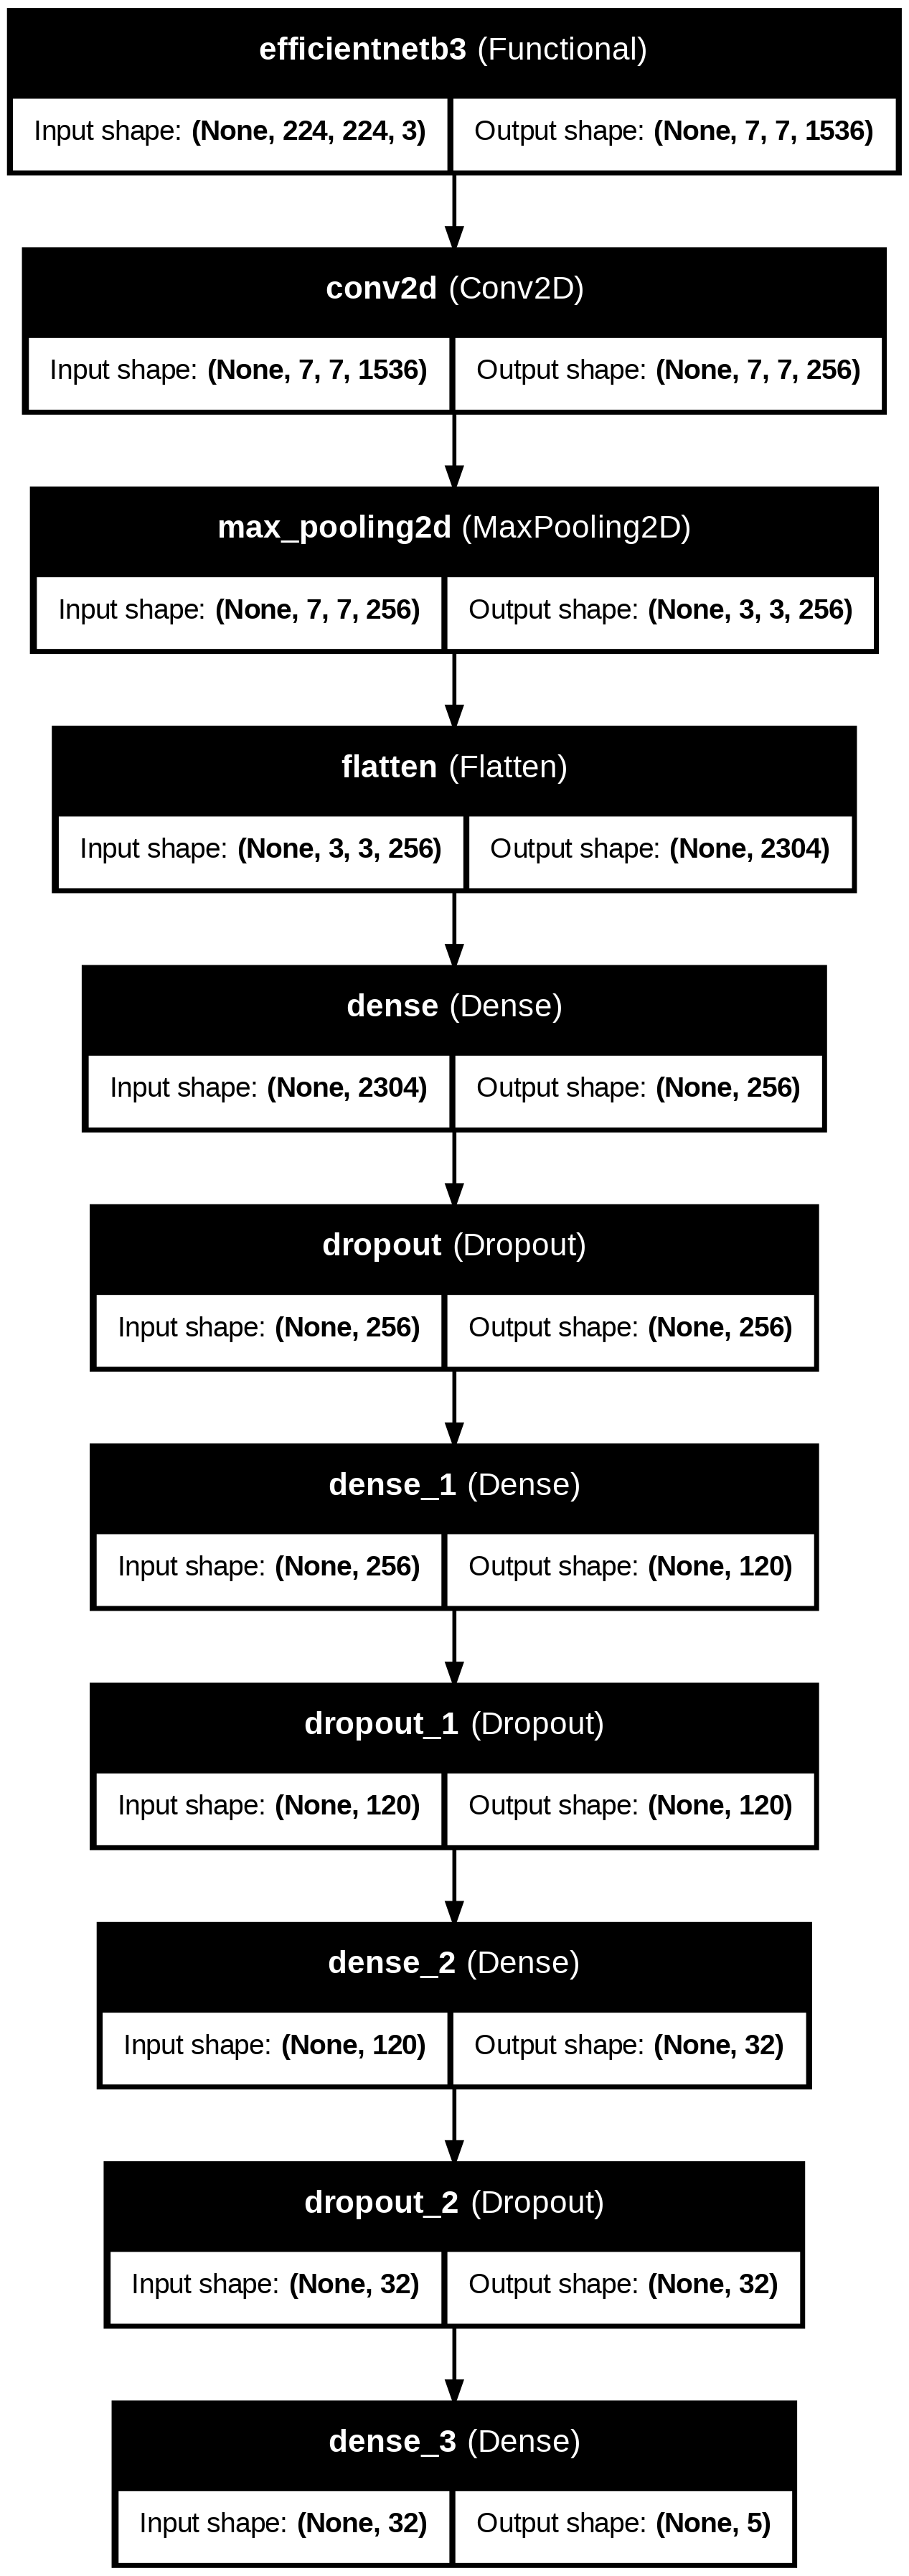

In [15]:
# Import library yang diperlukan
from tensorflow.keras.applications import EfficientNetB3  # Import arsitektur EfficientNetB3 sebagai base model
from tensorflow.keras.models import Sequential  # Import Sequential API untuk membangun model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # Import layer yang digunakan
from tensorflow.keras.optimizers import Adam  # Import optimizer Adam
from tensorflow.keras.utils import plot_model  # Import fungsi untuk memvisualisasikan arsitektur model

# Membuat base model menggunakan EfficientNetB3
base_model = EfficientNetB3(
    weights='imagenet',  # Menggunakan bobot pre-trained dari dataset ImageNet
    include_top=False,  # Tidak menyertakan fully connected layer di bagian atas (akan ditambahkan sendiri)
    input_shape=(224, 224, 3)  # Ukuran input gambar (224x224 piksel dengan 3 channel warna/RGB)
)
base_model.trainable = True  # Mengatur base model agar dapat dilatih ulang (fine-tuning)

# Membuat model sequential untuk klasifikasi
model = Sequential()

# Menambahkan base model (EfficientNetB3) sebagai lapisan pertama
model.add(base_model)  # Base model digunakan sebagai extractor fitur

# Menambahkan layer konvolusi untuk mengekstraksi fitur tambahan
model.add(Conv2D(
    filters=256,  # Jumlah filter konvolusi
    kernel_size=(3, 3),  # Ukuran kernel konvolusi (3x3)
    activation='relu',  # Fungsi aktivasi menggunakan ReLU
    padding='same'  # Padding untuk menjaga ukuran output tetap sama dengan input
))

# Menambahkan layer pooling untuk mengurangi ukuran dimensi fitur
model.add(MaxPooling2D(
    pool_size=(2, 2)  # Ukuran pooling (2x2), mengurangi dimensi fitur setengahnya
))

# Menambahkan layer Flatten untuk mengubah tensor 2D menjadi vektor 1D
model.add(Flatten())

# Menambahkan fully connected layer pertama dengan 256 neuron
model.add(Dense(
    units=256,  # Jumlah neuron
    activation='relu'  # Fungsi aktivasi menggunakan ReLU
))

# Menambahkan dropout untuk mencegah overfitting (mengabaikan 30% neuron secara acak)
model.add(Dropout(rate=0.3))

# Menambahkan fully connected layer kedua dengan 120 neuron
model.add(Dense(
    units=120,  # Jumlah neuron
    activation='relu'  # Fungsi aktivasi menggunakan ReLU
))

# Menambahkan dropout untuk mencegah overfitting (mengabaikan 30% neuron secara acak)
model.add(Dropout(rate=0.3))

# Menambahkan fully connected layer ketiga dengan 32 neuron
model.add(Dense(
    units=32,  # Jumlah neuron
    activation='relu'  # Fungsi aktivasi menggunakan ReLU
))

# Menambahkan dropout untuk mencegah overfitting (mengabaikan 30% neuron secara acak)
model.add(Dropout(rate=0.3))

# Menambahkan output layer dengan 5 neuron (jumlah kelas) dan fungsi aktivasi softmax
model.add(Dense(
    units=5,  # Jumlah neuron output sesuai dengan jumlah kelas
    activation='softmax'  # Fungsi aktivasi softmax untuk probabilitas output
))

# Kompilasi model dengan optimizer, loss function, dan metrik
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Optimizer Adam dengan learning rate 0.00001
    loss='categorical_crossentropy',  # Loss function untuk klasifikasi multi-kelas
    metrics=['accuracy']  # Metrik evaluasi akurasi
)

# Menampilkan ringkasan arsitektur model
model.summary()

# Memvisualisasikan arsitektur model dan menampilkan bentuk setiap layer
plot_model(model, show_shapes=True, show_layer_names=True)

trainn

In [16]:
# Import library yang diperlukan
from sklearn.utils.class_weight import compute_class_weight  # Untuk menghitung bobot kelas
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint  # Callbacks untuk pelatihan

# Menghitung bobot kelas untuk menangani ketidakseimbangan kelas pada dataset
class_weights = compute_class_weight(
    class_weight='balanced',  # Strategi balancing untuk menghitung bobot
    classes=np.unique(train_generator.classes),  # Daftar kelas unik dari data latih
    y=train_generator.classes  # Label kelas dari data latih
)
class_weights = dict(enumerate(class_weights))  # Konversi list bobot ke dictionary agar dapat digunakan saat pelatihan

# Mendefinisikan daftar callbacks untuk meningkatkan performa pelatihan dan mencegah overfitting
callbacks = [
    EarlyStopping(
        patience=10,  # Hentikan pelatihan jika tidak ada peningkatan pada validasi selama 10 epoch
        restore_best_weights=True  # Kembalikan bobot model ke yang terbaik selama pelatihan
    ),
    ReduceLROnPlateau(
        factor=0.5,  # Kurangi learning rate sebesar 50% jika performa stagnan
        patience=3  # Tunggu hingga 3 epoch tanpa peningkatan sebelum mengurangi learning rate
    ),
    ModelCheckpoint(
        filepath='submission/best_model.keras',  # Path untuk menyimpan model terbaik
        save_best_only=True  # Hanya simpan model jika performa validasi membaik
    )
]

# --- Fase Pelatihan Pertama: Melatih hanya layer Dense ---
history1 = model.fit(
    train_generator,  # Data latih yang di-augmentasi
    epochs=20,  # Jumlah maksimal epoch untuk pelatihan fase pertama
    validation_data=validation_generator,  # Data validasi untuk mengevaluasi performa selama pelatihan
    class_weight=class_weights,  # Bobot kelas untuk menangani ketidakseimbangan kelas
    callbacks=callbacks,  # Daftar callbacks yang akan digunakan selama pelatihan
    verbose=1  # Menampilkan log pelatihan di konsol
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 370s 814ms/step - accuracy: 0.2938 - loss: 1.9418 - val_accuracy: 0.4245 - val_loss: 1.4063 - learning_rate: 1.0000e-05
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 174s 577ms/step - accuracy: 0.6051 - loss: 0.9988 - val_accuracy: 0.8237 - val_loss: 0.5247 - learning_rate: 1.0000e-05
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 176s 583ms/step - accuracy: 0.7200 - loss: 0.7060 - val_accuracy: 0.9174 - val_loss: 0.2786 - learning_rate: 1.0000e-05
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 172s 572ms/step - accuracy: 0.7950 - loss: 0.5357 - val_accuracy: 0.8990 - val_loss: 0.2997 - learning_rate: 1.0000e-05
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 173s 575ms/step - accuracy: 0.8437 - loss: 0.4238 - val_accuracy: 0.9184 - val_loss: 0.2152 - learning_rate: 1.0000e-05
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 174s 579ms/step - accuracy: 0.8708 - loss: 0.3601 - val_accuracy: 0.9437 - val_loss: 0.1489 - learning_rate: 1.0000e-05
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 

## Evaluasi dan Visualisasi

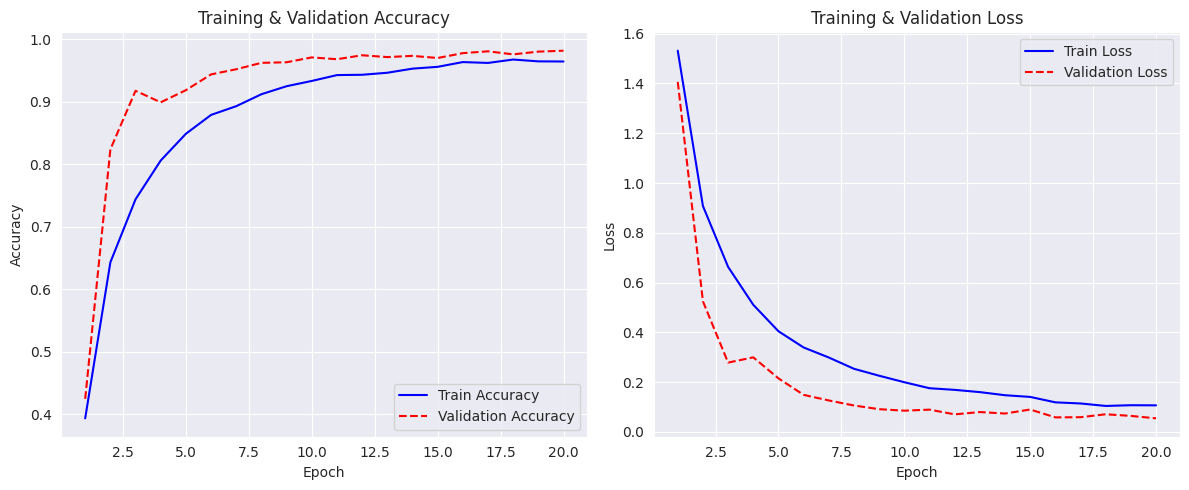

In [17]:
# Mengambil data metrik pelatihan dari objek history
train_accuracy = history1.history['accuracy']  # Akurasi pada data latih
val_accuracy = history1.history['val_accuracy']  # Akurasi pada data validasi
train_loss = history1.history['loss']  # Loss pada data latih
val_loss = history1.history['val_loss']  # Loss pada data validasi
epochs = range(1, len(train_accuracy) + 1)  # Rentang epoch (dimulai dari 1 hingga jumlah epoch)

# Membuat visualisasi untuk akurasi dan loss
import matplotlib.pyplot as plt  # Import library untuk membuat plot

plt.figure(figsize=(12, 5))  # Mengatur ukuran keseluruhan figure (12x5)

# Plot pertama: Akurasi untuk training dan validasi
plt.subplot(1, 2, 1)  # Membuat subplot pertama (1 baris, 2 kolom, posisi 1)
plt.plot(epochs, train_accuracy, 'b-', label='Train Accuracy')  # Plot akurasi pada data latih (garis biru solid)
plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')  # Plot akurasi pada data validasi (garis merah putus-putus)
plt.title('Training & Validation Accuracy')  # Judul untuk plot akurasi
plt.xlabel('Epoch')  # Label sumbu x
plt.ylabel('Accuracy')  # Label sumbu y
plt.legend()  # Menampilkan legenda untuk menjelaskan garis

# Plot kedua: Loss untuk training dan validasi
plt.subplot(1, 2, 2)  # Membuat subplot kedua (1 baris, 2 kolom, posisi 2)
plt.plot(epochs, train_loss, 'b-', label='Train Loss')  # Plot loss pada data latih (garis biru solid)
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')  # Plot loss pada data validasi (garis merah putus-putus)
plt.title('Training & Validation Loss')  # Judul untuk plot loss
plt.xlabel('Epoch')  # Label sumbu x
plt.ylabel('Loss')  # Label sumbu y
plt.legend()  # Menampilkan legenda untuk menjelaskan garis

# Menampilkan plot
plt.tight_layout()  # Mengatur tata letak agar kedua plot tidak saling bertumpukan
plt.show()  # Menampilkan visualisasi

In [18]:
# Mengevaluasi performa model pada dataset latih
# Fungsi evaluate() digunakan untuk menghitung nilai loss dan akurasi berdasarkan dataset yang diberikan
train_loss, train_accuracy = model.evaluate(
    train_generator,  # Data latih yang akan dievaluasi
    verbose=1  # Menampilkan progress evaluasi di konsol
)

# Mengevaluasi performa model pada dataset uji
# Dataset uji bersifat unseen (tidak pernah dilihat model selama pelatihan)
test_loss, test_accuracy = model.evaluate(
    test_generator,  # Data uji yang akan dievaluasi
    verbose=1  # Menampilkan progress evaluasi di konsol
)

# Menampilkan hasil evaluasi model untuk data latih
# Akurasi ditampilkan dalam persentase dengan format 2 desimal
print(f"\nTrain Accuracy: {train_accuracy * 100:.2f}%")  # Mengonversi akurasi menjadi persentase
print(f"Train Loss: {train_loss:.4f}")  # Menampilkan nilai loss dengan 4 angka desimal

# Menampilkan hasil evaluasi model untuk data uji
# Akurasi juga ditampilkan dalam persentase, sementara loss ditampilkan dalam format desimal
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")  # Mengonversi akurasi menjadi persentase
print(f"Test Loss: {test_loss:.4f}")  # Menampilkan nilai loss dengan 4 angka desimal

301/301 ━━━━━━━━━━━━━━━━━━━━ 146s 485ms/step - accuracy: 0.9922 - loss: 0.0240
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - accuracy: 0.9903 - loss: 0.0283

Train Accuracy: 99.29%
Train Loss: 0.0221

Test Accuracy: 97.23%
Test Loss: 0.0806


2059/2059 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step
Classification Report:
              precision    recall  f1-score   support

         cat       1.00      1.00      1.00       410
         dog       1.00      1.00      1.00       394
    elephant       0.92      0.98      0.95       410
       horse       0.98      0.93      0.95       443
        lion       0.96      0.96      0.96       402

    accuracy                           0.97      2059
   macro avg       0.97      0.97      0.97      2059
weighted avg       0.97      0.97      0.97      2059



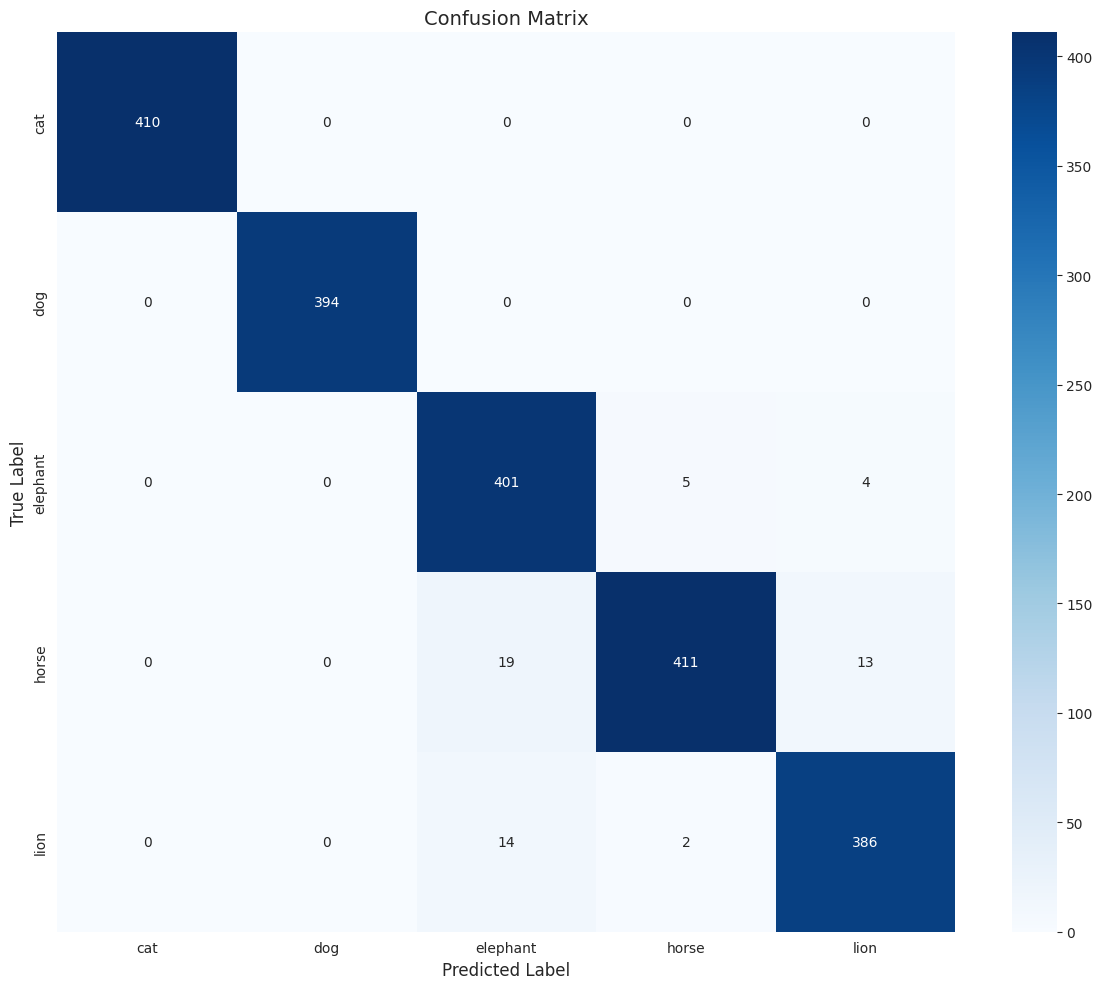

In [19]:
# Melakukan prediksi pada data uji menggunakan model yang sudah dilatih
# Hasil prediksi berupa probabilitas untuk setiap kelas
y_pred = model.predict(test_generator)  # Memproses data uji melalui model untuk mendapatkan prediksi

# Since y_pred is a dictionary, and we are doing single-output classification,
# we need to get the output from the correct key, which is likely 'output_0'
# based on your global variables.

y_pred_classes = np.argmax(y_pred, axis=1)  # Mengambil indeks kelas dengan probabilitas tertinggi (prediksi akhir)

# Mendapatkan label asli dari data uji
y_true = test_generator.classes  # Label asli dari data uji
class_labels = list(test_generator.class_indices.keys())  # Mendapatkan daftar nama kelas dari generator

# Menampilkan Classification Report
# Classification report memberikan metrik seperti precision, recall, f1-score untuk setiap kelas
print("Classification Report:")
print(classification_report(
    y_true,  # Label asli
    y_pred_classes,  # Label hasil prediksi
    target_names=class_labels  # Nama-nama kelas
))

# Membuat Confusion Matrix
# Confusion matrix memberikan gambaran jumlah prediksi benar dan salah untuk setiap kelas
confusion_mat = confusion_matrix(y_true, y_pred_classes)  # Membuat confusion matrix dari label asli dan prediksi
plt.figure(figsize=(12, 10))  # Mengatur ukuran figure untuk heatmap
sns.heatmap(
    confusion_mat,  # Data confusion matrix
    annot=True,  # Menampilkan nilai angka pada setiap sel
    fmt='d',  # Format angka dalam bentuk integer (digit)
    cmap='Blues',  # Skema warna biru untuk heatmap
    xticklabels=class_labels,  # Label pada sumbu x (prediksi)
    yticklabels=class_labels  # Label pada sumbu y (label asli)
)
plt.ylabel('True Label', fontsize=12)  # Label sumbu y
plt.xlabel('Predicted Label', fontsize=12)  # Label sumbu x
plt.title('Confusion Matrix', fontsize=14)  # Judul heatmap
plt.tight_layout()  # Menyesuaikan tata letak agar lebih rapi
plt.show()  # Menampilkan heatmap confusion matrix

## Konversi Model

In [27]:
model.export('/content/submission/saved_model')

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_385')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134605316620368: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134605318748880: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134605332308112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605332303888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605332304848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605332305424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605319116688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605287907088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605287909584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605287908240: TensorSpec(shape=(), dtype=tf.

In [28]:
# Mengkonversi model Keras menjadi model TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Membuat direktori untuk menyimpan model TFLite jika belum ada
# Parameter exist_ok=True membuat tidak error jika direktori sudah ada
os.makedirs("/content/submission/tflite", exist_ok=True)

# Menyimpan model dalam format .tflite
# "wb" berarti write binary (menulis file biner)
with open("/content/submission/tflite/model.tflite", "wb") as f:
    f.write(tflite_model)  # Menulis data model biner ke file

# Menyimpan label kelas untuk klasifikasi (jika model adalah classifier)
# Mengambil nama kelas dari generator data training
class_names = list(train_generator.class_indices.keys())
# Menyimpan label ke file teks
with open("/content/submission/tflite/label.txt", "w") as f:
    f.write("\n".join(class_names))

Saved artifact at '/tmp/tmpa7so8tr0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_385')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134605316620368: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134605318748880: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134605332308112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605332303888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605332304848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605332305424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605319116688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605287907088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605287909584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134605287908240: TensorSpec(shape=(), dtype=tf.resource, name=

In [29]:
!pip install tensorflowjs
!tensorflowjs_converter --input_format=tf_saved_model /content/submission/saved_model /content/submission/tfjs_model

2025-05-03 00:01:17.897787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746230477.929690   21557 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746230477.939442   21557 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-05-03 00:01:23.003221: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1746230483.003392   21557 gpu_device.cc:2022] Created device /job:localhost/replica:0/task

In [30]:
!pip freeze > /content/submission/requirements.txt

In [31]:
# ZIP folder submission
!zip -r /content/submission.zip /content/submission

# Download zip-nya
from google.colab import files
files.download("/content/submission.zip")

updating: content/submission/ (stored 0%)
updating: content/submission/tflite/ (stored 0%)
updating: content/submission/tflite/model.tflite (deflated 7%)
updating: content/submission/tflite/label.txt (stored 0%)
updating: content/submission/tfjs_model/ (stored 0%)
updating: content/submission/best_model.keras (deflated 9%)
updating: content/submission/requirements.txt (deflated 57%)
  adding: content/submission/saved_model/ (stored 0%)
  adding: content/submission/saved_model/variables/ (stored 0%)
  adding: content/submission/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: content/submission/saved_model/variables/variables.index (deflated 76%)
  adding: content/submission/saved_model/saved_model.pb (deflated 91%)
  adding: content/submission/saved_model/fingerprint.pb (stored 0%)
  adding: content/submission/saved_model/assets/ (stored 0%)
  adding: content/submission/tfjs_model/group1-shard10of15.bin (deflated 7%)
  adding: content/submission/tfjs_model/gr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Predicted class: chicken
Confidence: 100.00%


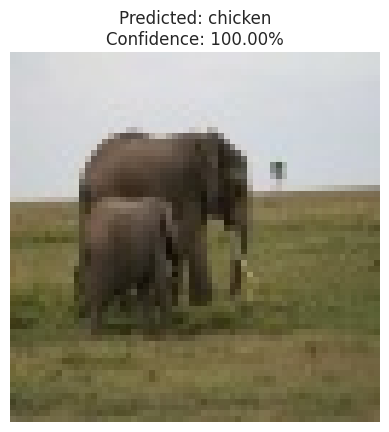

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import os

# Load the trained model

model = load_model('/content/submission/best_model.keras')

# Define class names (sesuaikan dengan urutan kelas saat training)
class_names = ["cat", "dog", "elephant", "horse", "lion"]

# Function to preprocess image for prediction
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalisasi seperti saat training
    return img_array

# Function to make prediction
def predict_animal(model, img_path):
    # Preprocess the image
    processed_img = preprocess_image(img_path)

    # Make prediction
    predictions = model.predict(processed_img)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    # Get class name
    class_name = class_names[predicted_class]

    return class_name, confidence

# Function to display prediction result
def display_prediction(img_path, class_name, confidence):
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted: {class_name}\nConfidence: {confidence:.2f}%')
    plt.show()

# Test with a single image
# test_image_path = '/path/to/your/test_image.jpg'  # Ganti dengan path gambar Anda
test_image_path = "/content/sample_data/submission/test/elephant/elephant100.jpg" # Updated with a valid path from your dataset
class_name, confidence = predict_animal(model, test_image_path)
print(f'Predicted class: {class_name}')
print(f'Confidence: {confidence*100:.2f}%')

# Display the result
display_prediction(test_image_path, class_name, confidence*100)

# Alternatively, you can test with multiple images in a directory
def test_directory(model, directory_path):
    for img_file in os.listdir(directory_path):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(directory_path, img_file)
            try:
                class_name, confidence = predict_animal(model, img_path)
                print(f'Image: {img_file}')
                print(f'Predicted: {class_name} ({confidence*100:.2f}%)')
                print('---')
            except Exception as e:
                print(f'Error processing {img_file}: {e}')

# Uncomment to test a directory
# test_directory(model, '/path/to/your/test_images/') # Replace with a valid directory if needed

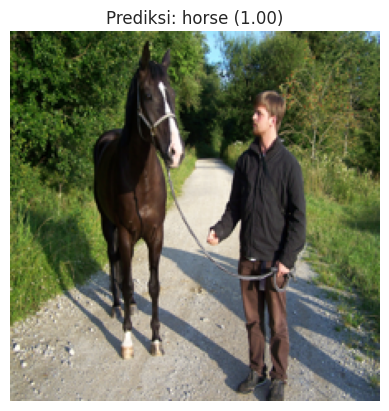

Probabilitas untuk setiap kelas:
cat       : 0.00
dog       : 0.00
elephant  : 0.00
horse     : 1.00
lion      : 0.00


In [43]:
# Import library yang diperlukan
import numpy as np  # Untuk manipulasi array dan operasi numerik
import matplotlib.pyplot as plt  # Untuk visualisasi gambar dan hasil prediksi
from PIL import Image  # Untuk memuat dan memproses gambar
import tensorflow as tf  # Untuk menggunakan TensorFlow Lite interpreter

# Step 1: Memuat model TFLite
# Model telah dikonversi ke format TensorFlow Lite dan disimpan di path yang ditentukan
model_path = "/content/submission/tflite/model.tflite"  # Path ke file model TFLite
interpreter = tf.lite.Interpreter(model_path=model_path)  # Memuat model TFLite ke interpreter
interpreter.allocate_tensors()  # Mengalokasikan tensor untuk mempersiapkan inference

# Step 2: Mendapatkan informasi input dan output model
# Informasi ini berguna untuk memastikan format input dan output sesuai
input_details = interpreter.get_input_details()  # Informasi tentang input model
output_details = interpreter.get_output_details()  # Informasi tentang output model

# Step 3: Memuat dan memproses gambar input
# Gambar akan diproses agar sesuai dengan format yang diperlukan oleh model
img_path = "/content/sample_data/submission/test/horse/horse1102.jpg"  # Path ke gambar yang akan diprediksi
img = Image.open(img_path).resize((224, 224))  # Memuat gambar dan mengubah ukurannya menjadi 224x224 piksel
img_array = np.array(img).astype(np.float32) / 255.0  # Mengonversi gambar ke array NumPy dan menormalisasi ke rentang [0, 1]
img_array = np.expand_dims(img_array, axis=0)  # Menambahkan dimensi batch agar array memiliki bentuk (1, 224, 224, 3)

# Step 4: Melakukan inference menggunakan model TFLite
# Memberikan gambar input ke model dan mendapatkan hasil prediksi
interpreter.set_tensor(input_details[0]['index'], img_array)  # Mengatur tensor input dengan data gambar
interpreter.invoke()  # Memulai proses inference pada model
output_data = interpreter.get_tensor(output_details[0]['index'])[0]  # Mengambil hasil prediksi dari tensor output

# Step 5: Mendefinisikan label kelas
# Label kelas digunakan untuk memetakan hasil prediksi ke nama kelas yang sesuai
class_names = ["cat", "dog", "elephant", "horse", "lion"]  # Daftar nama kelas

# Step 6: Menampilkan gambar input beserta hasil prediksi terbaik
# Visualisasi gambar dengan anotasi berupa nama kelas yang diprediksi dan confidence score
plt.imshow(img)  # Menampilkan gambar input
plt.axis('off')  # Menghilangkan sumbu pada tampilan gambar
predicted_class_index = np.argmax(output_data)  # Mendapatkan indeks kelas dengan probabilitas tertinggi
predicted_class_prob = output_data[predicted_class_index]  # Mendapatkan probabilitas kelas tertinggi
plt.title(f"Prediksi: {class_names[predicted_class_index]} ({predicted_class_prob:.2f})")  # Menambahkan judul dengan prediksi
plt.show()  # Menampilkan gambar dan hasil prediksi

# Step 7: Menampilkan semua skor probabilitas untuk setiap kelas
# Probabilitas setiap kelas ditampilkan dalam format teks
print("Probabilitas untuk setiap kelas:")
for index, probability in enumerate(output_data):  # Iterasi melalui indeks dan probabilitas
    print(f"{class_names[index]:<10}: {probability:.2f}")  # Menampilkan nama kelas dan probabilitas dengan format rapi